<a href="https://colab.research.google.com/github/taniaababneh0-ui/project-WiDS/blob/main/WiDs_Project_Main.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#Read files

In [176]:
from google.colab import files
uploaded = files.upload()


Saving WiDSWorldWide_GlobalDathon26.zip to WiDSWorldWide_GlobalDathon26 (4).zip


In [177]:
import pandas as pd
import numpy as np
import zipfile

# Unzip the uploaded file if it's a zip archive
zip_file_name = 'WiDSWorldWide_GlobalDathon26 (1).zip' # Adjust if the uploaded zip file name is different
with zipfile.ZipFile(zip_file_name, 'r') as zip_ref:
    zip_ref.extractall('.') # Extract all contents to the current directory

train_path = "train.csv"
test_path = "test.csv"
meta_path = "metaData.csv"
sample_sub_path = "sample_submission.csv"

train_df = pd.read_csv(train_path)
test_df = pd.read_csv(test_path)
meta_df = pd.read_csv(meta_path)
sample_sub_df = pd.read_csv(sample_sub_path)

#EDA

##General information about data

In [178]:
print("Train shape:", train_df.shape)
print("Test shape:", test_df.shape)
print("Metadata shape:", meta_df.shape)
print("Sample submission shape:", sample_sub_df.shape)


Train shape: (221, 37)
Test shape: (95, 35)
Metadata shape: (37, 6)
Sample submission shape: (95, 5)


In [179]:
print("train_df.columns = ",train_df.columns.tolist())
print("test_df.columns = ",test_df.columns.tolist())


train_df.columns =  ['event_id', 'num_perimeters_0_5h', 'dt_first_last_0_5h', 'low_temporal_resolution_0_5h', 'area_first_ha', 'area_growth_abs_0_5h', 'area_growth_rel_0_5h', 'area_growth_rate_ha_per_h', 'log1p_area_first', 'log1p_growth', 'log_area_ratio_0_5h', 'relative_growth_0_5h', 'radial_growth_m', 'radial_growth_rate_m_per_h', 'centroid_displacement_m', 'centroid_speed_m_per_h', 'spread_bearing_deg', 'spread_bearing_sin', 'spread_bearing_cos', 'dist_min_ci_0_5h', 'dist_std_ci_0_5h', 'dist_change_ci_0_5h', 'dist_slope_ci_0_5h', 'closing_speed_m_per_h', 'closing_speed_abs_m_per_h', 'projected_advance_m', 'dist_accel_m_per_h2', 'dist_fit_r2_0_5h', 'alignment_cos', 'alignment_abs', 'cross_track_component', 'along_track_speed', 'event_start_hour', 'event_start_dayofweek', 'event_start_month', 'time_to_hit_hours', 'event']
test_df.columns =  ['event_id', 'num_perimeters_0_5h', 'dt_first_last_0_5h', 'low_temporal_resolution_0_5h', 'area_first_ha', 'area_growth_abs_0_5h', 'area_growth_r

In [180]:
print("train_df\n ",train_df.info(),"\n")
print("test_df \n",test_df.info(),"\n")

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 221 entries, 0 to 220
Data columns (total 37 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   event_id                      221 non-null    int64  
 1   num_perimeters_0_5h           221 non-null    int64  
 2   dt_first_last_0_5h            221 non-null    float64
 3   low_temporal_resolution_0_5h  221 non-null    int64  
 4   area_first_ha                 221 non-null    float64
 5   area_growth_abs_0_5h          221 non-null    float64
 6   area_growth_rel_0_5h          221 non-null    float64
 7   area_growth_rate_ha_per_h     221 non-null    float64
 8   log1p_area_first              221 non-null    float64
 9   log1p_growth                  221 non-null    float64
 10  log_area_ratio_0_5h           221 non-null    float64
 11  relative_growth_0_5h          221 non-null    float64
 12  radial_growth_m               221 non-null    float64
 13  radia

In [181]:
train_missing = train_df.isnull().sum().sum()
test_missing = test_df.isnull().sum().sum()

print(f"Total missing in train: {train_missing}")
print(f"Total missing in test: {test_missing}")

Total missing in train: 0
Total missing in test: 0




---



##Distribution of event

عمود الـ 0 أكبر من 1

التفسير:
في عدد أكبر من الحرائق ما وصلت

dataset فيها imbalance

شو يعني للمسابقة؟
الموديل ممكن يتعلم يقول "0" كثير  ويكون شكله دقيق لكنه غلط

لازم لاحقًا:

نستخدم class weights
أو ننتبه للـ evaluation

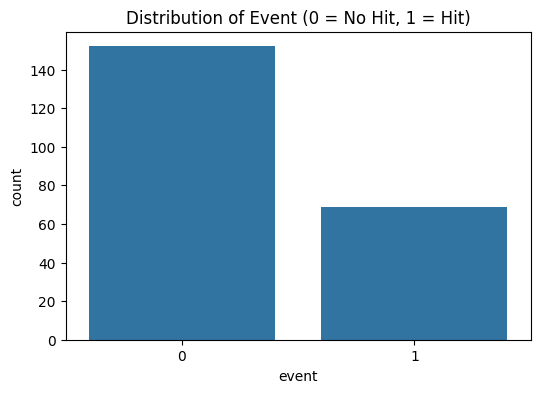

In [182]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(6,4))
sns.countplot(x=train_df['event'])
plt.title("Distribution of Event (0 = No Hit, 1 = Hit)")
plt.show()

##Time distribution

توزيع القيم من 0 إلى ~72

skewed (مش متوازن)

 التفسير:

بعض الحرائق توصل بسرعة
وبعضها يأخذ وقت طويل
وبعضها ما يوصل (censored)

شو يعني؟

المشكلة مش binary بس
فيها بعد زمني مهم جدًا

 وهذا سبب:

ليش المسابقة تطلب probabilities عبر الزمن

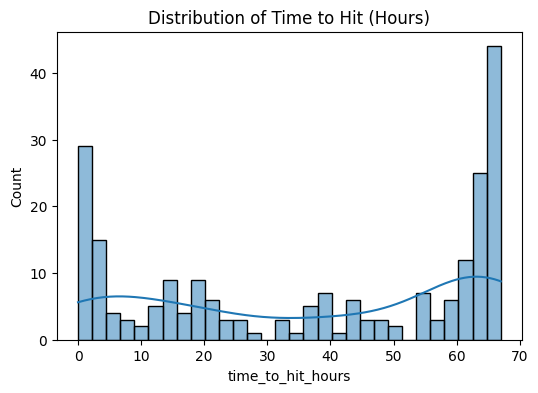

In [183]:
plt.figure(figsize=(6,4))
sns.histplot(train_df['time_to_hit_hours'], bins=30, kde=True)
plt.title("Distribution of Time to Hit (Hours)")
plt.show()

##Compare features with event

التفسيرات

A) dist_min_ci_0_5h (المسافة)

    event=1 → القيم أصغر
    event=0 → القيم أكبر
    الحريق إذا قريب → احتمال يوصل أعلى

B) closing_speed_m_per_h

    event=1 → أعلى
    event=0 → أقل
    كل ما الحريق عم يقرب أسرع → خطر أعلى

C) area_growth_rate_ha_per_h

    event=1 → أعلى
    event=0 → أقل

    الحريق اللي يكبر بسرعة → يوصل أسرع

D) centroid_speed_m_per_h

    event=1 → أعلى
    event=0 → أقل

    الحريق عم يتحرك بسرعة → ممكن ينتشر أسرع

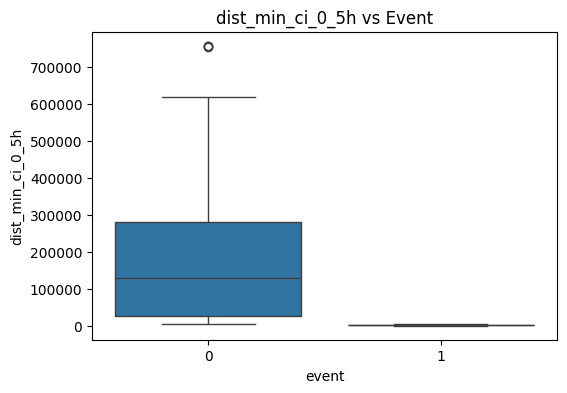

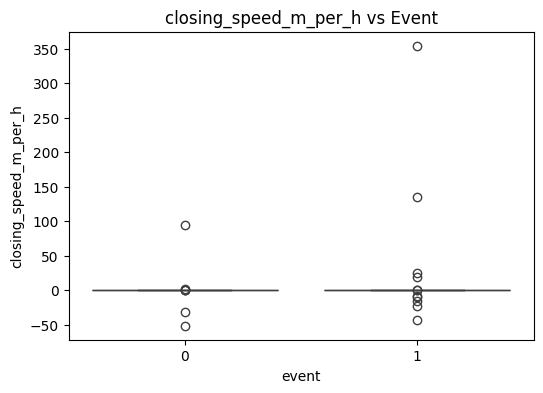

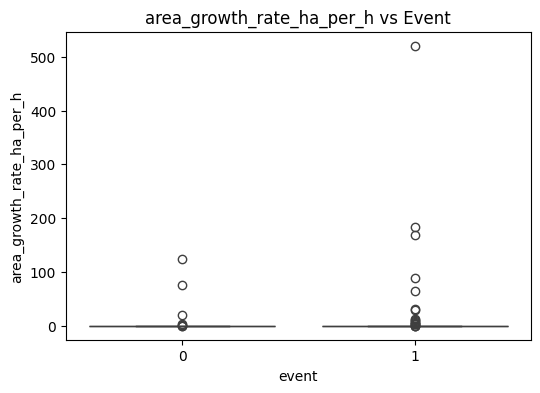

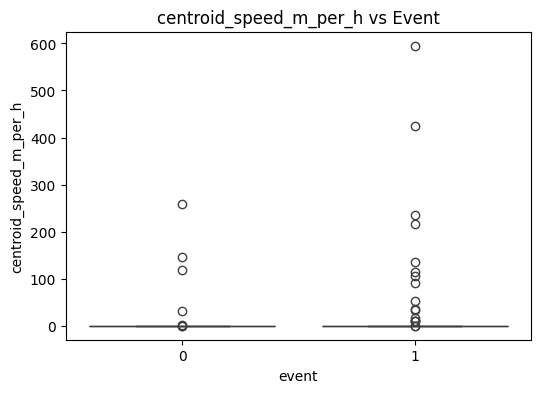

In [184]:
important_features = [
    'dist_min_ci_0_5h',
    'closing_speed_m_per_h',
    'area_growth_rate_ha_per_h',
    'centroid_speed_m_per_h'
]

for col in important_features:
    plt.figure(figsize=(6,4))
    sns.boxplot(x='event', y=col, data=train_df)
    plt.title(f"{col} vs Event")
    plt.show()

##Correlation

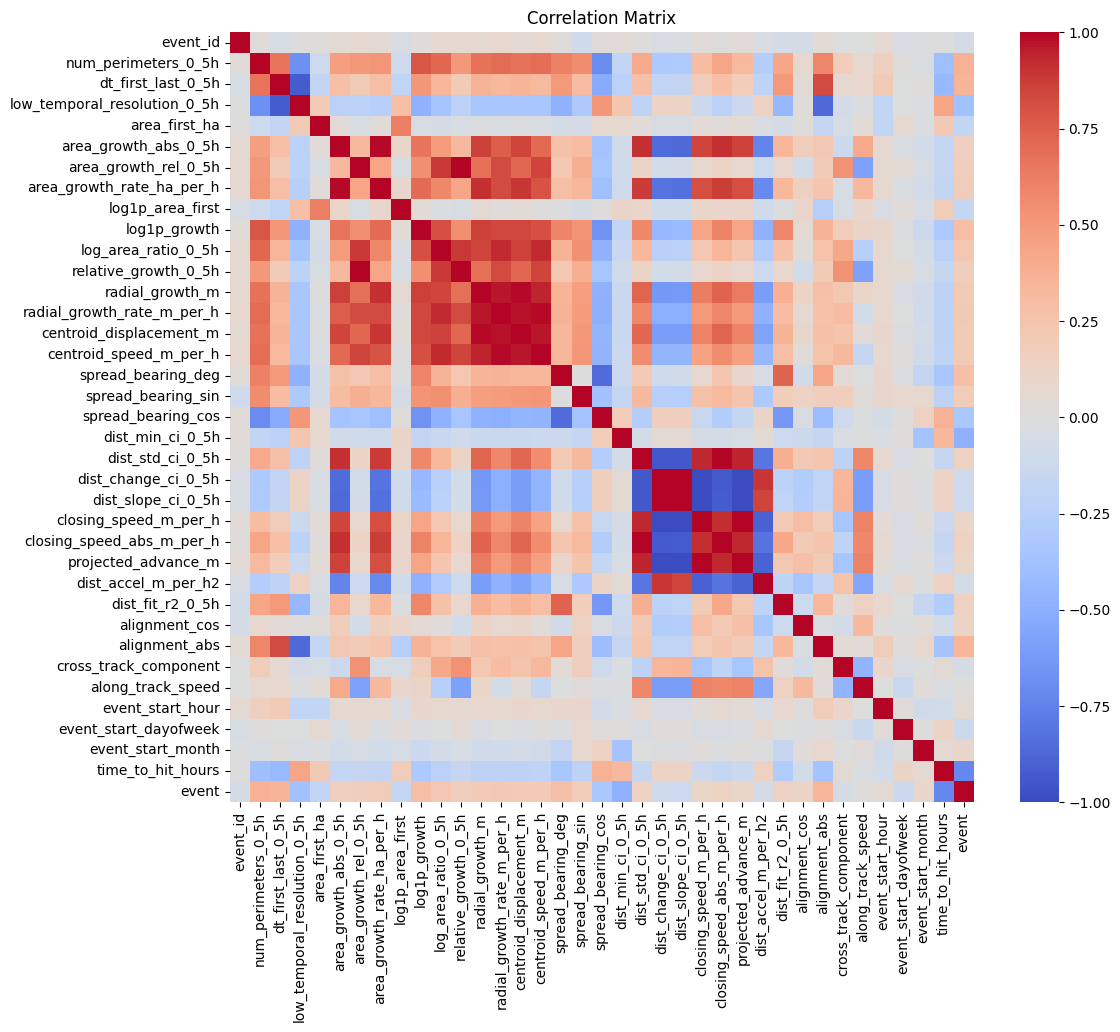

In [185]:
plt.figure(figsize=(12,10))
corr = train_df.corr()
sns.heatmap(corr, cmap='coolwarm')
plt.title("Correlation Matrix")
plt.show()

##Most important features

أعلى features مثل:

closing_speed

distance features

growth

`لها تأثير مباشر على وصول الحريق`

أقل features

    هاي ما بتفرق كثير
    ممكن تكون noise


In [186]:
corr_with_target = corr['event'].sort_values(ascending=False)

print("\nTop correlated with event:")
print(corr_with_target.head(10))

print("\nLeast correlated with event:")
print(corr_with_target.tail(10))


Top correlated with event:
event                         1.000000
num_perimeters_0_5h           0.370501
dt_first_last_0_5h            0.352954
alignment_abs                 0.349115
log1p_growth                  0.292688
spread_bearing_deg            0.281012
log_area_ratio_0_5h           0.229327
radial_growth_rate_m_per_h    0.214956
radial_growth_m               0.209343
centroid_speed_m_per_h        0.209254
Name: event, dtype: float64

Least correlated with event:
dist_accel_m_per_h2            -0.072594
dist_change_ci_0_5h            -0.106449
dist_slope_ci_0_5h             -0.115274
event_start_dayofweek          -0.119334
log1p_area_first               -0.167912
area_first_ha                  -0.181334
spread_bearing_cos             -0.323189
low_temporal_resolution_0_5h   -0.379117
dist_min_ci_0_5h               -0.481379
time_to_hit_hours              -0.719485
Name: event, dtype: float64


#Preprocessing

##Defining the basic pillars in our work

In [187]:
id_col = "event_id"
target_time_col = "time_to_hit_hours"
target_event_col = "event"

##Data separation

في train_df:

    1.يحذف event_id
    2.ويحذف event
    3.ويحذف time_to_hit_hours

    ويبقي فقط الـ features

في test_df:

    يحذف event_id

    ويبقي كل الأعمدة الأخرى لأنها كلها features

يفصل الهدف إلى جزئين:

    y_event: متغير الحدث
    y_time: متغير الزمن
ليش فصلناهم؟

لأننا لاحقًا قد نستخدم:

y_event →  لبناء أهداف مثل: هل يصل خلال 12 ساعة؟

y_time → لاشتقاق أهداف زمنية أو حل survival

In [188]:
X_train = train_df.drop(columns=[id_col, target_event_col, target_time_col]).copy()
X_test = test_df.drop(columns=[id_col]).copy()

y_event = train_df[target_event_col].copy()
y_time = train_df[target_time_col].copy()

يعرض أبعاد البيانات

In [189]:
print("Initial X_train shape:", X_train.shape)
print("Initial X_test shape:", X_test.shape)

print("\nX_train data types:")
print(X_train.dtypes.value_counts())

Initial X_train shape: (221, 34)
Initial X_test shape: (95, 34)

X_train data types:
float64    29
int64       5
Name: count, dtype: int64


##Identifying numerical columns

In [190]:
numeric_cols = X_train.select_dtypes(include=[np.number]).columns.tolist()

print("\nNumber of numeric columns:", len(numeric_cols))
print("Numeric columns sample:", numeric_cols[:10])


Number of numeric columns: 34
Numeric columns sample: ['num_perimeters_0_5h', 'dt_first_last_0_5h', 'low_temporal_resolution_0_5h', 'area_first_ha', 'area_growth_abs_0_5h', 'area_growth_rel_0_5h', 'area_growth_rate_ha_per_h', 'log1p_area_first', 'log1p_growth', 'log_area_ratio_0_5h']


##Skewness account

In [191]:
skewness = X_train[numeric_cols].skew().sort_values(ascending=False)

print("\nTop positively skewed features:")
print(skewness.head(10))


Top positively skewed features:
relative_growth_0_5h         11.951708
area_growth_rel_0_5h         11.951708
dist_std_ci_0_5h             11.589398
area_growth_abs_0_5h         11.231250
projected_advance_m          11.187420
closing_speed_abs_m_per_h    11.152232
closing_speed_m_per_h        10.994165
area_growth_rate_ha_per_h    10.281604
centroid_speed_m_per_h        6.959181
centroid_displacement_m       6.753091
dtype: float64


هذه الأعمدة منحرفة لليسار، لكنها غالبًا أقل أهمية من الأعمدة المنحرفة بقوة لليمين

In [192]:
print("\nTop negatively skewed features:")
print(skewness.tail(10))


Top negatively skewed features:
alignment_cos                   -0.030941
log1p_area_first                -0.111519
event_start_hour                -0.987353
low_temporal_resolution_0_5h    -1.034656
event_start_month               -1.187613
spread_bearing_cos              -3.486537
along_track_speed               -3.770071
dist_accel_m_per_h2             -8.269464
dist_change_ci_0_5h            -11.187420
dist_slope_ci_0_5h             -11.980702
dtype: float64


##Select the columns that need log transformation

يختار الأعمدة التي تحقق شرطين:

ما فيها قيم سالبة

الانحراف فيها كبير

In [193]:
skew_threshold = 1.0

log_transform_cols = [
    col for col in numeric_cols
    if X_train[col].min() >= 0 and abs(X_train[col].skew()) > skew_threshold
]

print("\nColumns selected for log1p transform:")
print(log_transform_cols)


Columns selected for log1p transform:
['num_perimeters_0_5h', 'dt_first_last_0_5h', 'low_temporal_resolution_0_5h', 'area_first_ha', 'log1p_growth', 'centroid_displacement_m', 'centroid_speed_m_per_h', 'spread_bearing_deg', 'dist_min_ci_0_5h', 'dist_std_ci_0_5h', 'closing_speed_abs_m_per_h', 'dist_fit_r2_0_5h', 'alignment_abs', 'event_start_month']


تطبيق log1p

In [194]:
for col in log_transform_cols:
    X_train[col] = np.log1p(X_train[col])
    X_test[col] = np.log1p(X_test[col])

حوّلنا الساعة واليوم والشهر لـ sin وcos لأنه هدول أشياء دورانية مش خطّية. يعني مثلاً الساعة 23 والساعة 0 فعليًا قريبين، بس بالأرقام الفرق بينهم كبير وهاي بتخبّص الموديل. نفس الشي للشهور . فإحنا بهالتحويل خلّينا الموديل يفهم إنهم دايرة مش خط، وهيك بصير يلقط الأنماط الزمنية صح ويعطينا توقعات أدق.

In [195]:
X_train["event_start_hour_sin"] = np.sin(2 * np.pi * X_train["event_start_hour"] / 24)
X_train["event_start_hour_cos"] = np.cos(2 * np.pi * X_train["event_start_hour"] / 24)

X_test["event_start_hour_sin"] = np.sin(2 * np.pi * X_test["event_start_hour"] / 24)
X_test["event_start_hour_cos"] = np.cos(2 * np.pi * X_test["event_start_hour"] / 24)


X_train["event_start_dayofweek_sin"] = np.sin(2 * np.pi * X_train["event_start_dayofweek"] / 7)
X_train["event_start_dayofweek_cos"] = np.cos(2 * np.pi * X_train["event_start_dayofweek"] / 7)

X_test["event_start_dayofweek_sin"] = np.sin(2 * np.pi * X_test["event_start_dayofweek"] / 7)
X_test["event_start_dayofweek_cos"] = np.cos(2 * np.pi * X_test["event_start_dayofweek"] / 7)


X_train["event_start_month_sin"] = np.sin(2 * np.pi * X_train["event_start_month"] / 12)
X_train["event_start_month_cos"] = np.cos(2 * np.pi * X_train["event_start_month"] / 12)

X_test["event_start_month_sin"] = np.sin(2 * np.pi * X_test["event_start_month"] / 12)
X_test["event_start_month_cos"] = np.cos(2 * np.pi * X_test["event_start_month"] / 12)

##Delete the original time columns

يجمع الأعمدة الخام التي لم نعد نحتاجهاوبعدها يحذف الأعمدة الزمنية الأصلية بعد أن صنعنا بدائل أفضل لها.



In [196]:
time_cols_to_drop = [
    "event_start_hour",
    "event_start_dayofweek",
    "event_start_month"
]

X_train = X_train.drop(columns=time_cols_to_drop)
X_test = X_test.drop(columns=time_cols_to_drop)

##New information about data

In [197]:
print("\nFinal X_train shape:", X_train.shape)
print("Final X_test shape:", X_test.shape)


Final X_train shape: (221, 37)
Final X_test shape: (95, 37)


In [198]:
print("\nFinal missing values in X_train:", X_train.isnull().sum().sum())
print("Final missing values in X_test:", X_test.isnull().sum().sum())


Final missing values in X_train: 0
Final missing values in X_test: 0


In [199]:
print("\nTrain/Test columns identical?", list(X_train.columns) == list(X_test.columns))


Train/Test columns identical? True


In [200]:
print("\nSample final columns:")
print(X_train.columns.tolist()[:20])


Sample final columns:
['num_perimeters_0_5h', 'dt_first_last_0_5h', 'low_temporal_resolution_0_5h', 'area_first_ha', 'area_growth_abs_0_5h', 'area_growth_rel_0_5h', 'area_growth_rate_ha_per_h', 'log1p_area_first', 'log1p_growth', 'log_area_ratio_0_5h', 'relative_growth_0_5h', 'radial_growth_m', 'radial_growth_rate_m_per_h', 'centroid_displacement_m', 'centroid_speed_m_per_h', 'spread_bearing_deg', 'spread_bearing_sin', 'spread_bearing_cos', 'dist_min_ci_0_5h', 'dist_std_ci_0_5h']


#Feature Engineering

In [201]:
X_train_fe = X_train.copy()
X_test_fe = X_test.copy()

##Features related to distance and proximity

كل ما كانت المسافة أقل، الخطر أعلى

In [202]:
X_train_fe["inv_dist_min_ci_0_5h"] = 1 / (X_train_fe["dist_min_ci_0_5h"] + 1)
X_test_fe["inv_dist_min_ci_0_5h"] = 1 / (X_test_fe["dist_min_ci_0_5h"] + 1)

نسبة سرعة الاقتراب إلى المسافة

In [203]:
X_train_fe["closing_to_distance_ratio"] = X_train_fe["closing_speed_m_per_h"] / (X_train_fe["dist_min_ci_0_5h"] + 1)
X_test_fe["closing_to_distance_ratio"] = X_test_fe["closing_speed_m_per_h"] / (X_test_fe["dist_min_ci_0_5h"] + 1)

projected advance نسبة إلى المسافة

In [204]:
X_train_fe["projected_advance_ratio"] = X_train_fe["projected_advance_m"] / (X_train_fe["dist_min_ci_0_5h"] + 1)
X_test_fe["projected_advance_ratio"] = X_test_fe["projected_advance_m"] / (X_test_fe["dist_min_ci_0_5h"] + 1)

##Features combine growth and distance

نمو الحريق نسبةً إلى قربه من منطقة الإخلاء

In [205]:
X_train_fe["growth_distance_interaction"] = X_train_fe["area_growth_rate_ha_per_h"] / (X_train_fe["dist_min_ci_0_5h"] + 1)
X_test_fe["growth_distance_interaction"] = X_test_fe["area_growth_rate_ha_per_h"] / (X_test_fe["dist_min_ci_0_5h"] + 1)


التوسع الشعاعي نسبة للمسافة

In [206]:
X_train_fe["radial_growth_distance_ratio"] = X_train_fe["radial_growth_rate_m_per_h"] / (X_train_fe["dist_min_ci_0_5h"] + 1)
X_test_fe["radial_growth_distance_ratio"] = X_test_fe["radial_growth_rate_m_per_h"] / (X_test_fe["dist_min_ci_0_5h"] + 1)

##Features combine movement and direction

السرعة باتجاه منطقة الإخلاء مع عامل الاتجاه

In [207]:
X_train_fe["directed_spread_speed"] = X_train_fe["along_track_speed"] * X_train_fe["alignment_cos"]
X_test_fe["directed_spread_speed"] = X_test_fe["along_track_speed"] * X_test_fe["alignment_cos"]

 شدة الحركة باتجاه الهدف بغض النظر عن الإشارة

In [208]:
X_train_fe["aligned_motion_strength"] = X_train_fe["centroid_speed_m_per_h"] * X_train_fe["alignment_abs"]
X_test_fe["aligned_motion_strength"] = X_test_fe["centroid_speed_m_per_h"] * X_test_fe["alignment_abs"]

##Features combine growth and proximity

إذا الحريق يكبر ويقترب بنفس الوقت فهذا خطر أعلى

In [209]:
X_train_fe["growth_closing_interaction"] = X_train_fe["area_growth_rate_ha_per_h"] * X_train_fe["closing_speed_m_per_h"]
X_test_fe["growth_closing_interaction"] = X_test_fe["area_growth_rate_ha_per_h"] * X_test_fe["closing_speed_m_per_h"]

النمو الشعاعي مع الاقتراب

In [210]:
X_train_fe["radial_closing_interaction"] = X_train_fe["radial_growth_rate_m_per_h"] * X_train_fe["closing_speed_m_per_h"]
X_test_fe["radial_closing_interaction"] = X_test_fe["radial_growth_rate_m_per_h"] * X_test_fe["closing_speed_m_per_h"]

##Features reflect the quality of the temporal/geometric signal.

إذا الـ fit الخطي ممتاز والإغلاق سريع، فالإشارة أقوى

In [211]:
X_train_fe["reliable_closing_signal"] = X_train_fe["dist_fit_r2_0_5h"] * X_train_fe["closing_speed_abs_m_per_h"]
X_test_fe["reliable_closing_signal"] = X_test_fe["dist_fit_r2_0_5h"] * X_test_fe["closing_speed_abs_m_per_h"]

 إذا temporal resolution منخفضة نقلل الثقة بإشارة الحركة

In [212]:
X_train_fe["temporal_penalized_closing"] = X_train_fe["closing_speed_abs_m_per_h"] * (1 - X_train_fe["low_temporal_resolution_0_5h"])
X_test_fe["temporal_penalized_closing"] = X_test_fe["closing_speed_abs_m_per_h"] * (1 - X_test_fe["low_temporal_resolution_0_5h"])

##Additional simple and useful features

فرق بين سرعة الحركة العامة وسرعة الاقتراب

In [213]:
X_train_fe["speed_minus_closing"] = X_train_fe["centroid_speed_m_per_h"] - X_train_fe["closing_speed_abs_m_per_h"]
X_test_fe["speed_minus_closing"] = X_test_fe["centroid_speed_m_per_h"] - X_test_fe["closing_speed_abs_m_per_h"]

شدة التوسع الكلي

In [214]:
X_train_fe["combined_growth_intensity"] = (
    X_train_fe["area_growth_rate_ha_per_h"] + X_train_fe["radial_growth_rate_m_per_h"]
)
X_test_fe["combined_growth_intensity"] = (
    X_test_fe["area_growth_rate_ha_per_h"] + X_test_fe["radial_growth_rate_m_per_h"]
)

##Check the final appearance

In [215]:
print("X_train_fe shape:", X_train_fe.shape)
print("X_test_fe shape:", X_test_fe.shape)

X_train_fe shape: (221, 50)
X_test_fe shape: (95, 50)


In [216]:
print("\nTrain/Test columns identical?", list(X_train_fe.columns) == list(X_test_fe.columns))


Train/Test columns identical? True


In [217]:
print("\nNewly added feature count:", X_train_fe.shape[1] - X_train.shape[1])


Newly added feature count: 13


In [218]:
new_cols = [col for col in X_train_fe.columns if col not in X_train.columns]

print("\nNew feature columns:")
for col in new_cols:
    print(col)


New feature columns:
inv_dist_min_ci_0_5h
closing_to_distance_ratio
projected_advance_ratio
growth_distance_interaction
radial_growth_distance_ratio
directed_spread_speed
aligned_motion_strength
growth_closing_interaction
radial_closing_interaction
reliable_closing_signal
temporal_penalized_closing
speed_minus_closing
combined_growth_intensity


###A quick check of the connection between new features and the event

In [219]:
temp_df = X_train_fe.copy()
temp_df["event"] = y_event.values

In [220]:
new_feature_corr = temp_df[new_cols + ["event"]].corr()["event"].sort_values(ascending=False)

In [221]:
print("\nTop new features positively correlated with event:")
print(new_feature_corr.head(10))


Top new features positively correlated with event:
event                           1.000000
inv_dist_min_ci_0_5h            0.851607
aligned_motion_strength         0.296399
speed_minus_closing             0.232006
radial_growth_distance_ratio    0.221610
combined_growth_intensity       0.201982
temporal_penalized_closing      0.199476
growth_distance_interaction     0.182472
directed_spread_speed           0.181431
reliable_closing_signal         0.175210
Name: event, dtype: float64


In [222]:
print("\nTop new features negatively correlated with event:")
print(new_feature_corr.tail(10))


Top new features negatively correlated with event:
radial_growth_distance_ratio    0.221610
combined_growth_intensity       0.201982
temporal_penalized_closing      0.199476
growth_distance_interaction     0.182472
directed_spread_speed           0.181431
reliable_closing_signal         0.175210
radial_closing_interaction      0.114528
closing_to_distance_ratio       0.110499
projected_advance_ratio         0.110100
growth_closing_interaction      0.106600
Name: event, dtype: float64


#Equip Targets for Regular Classification Models

كل متغير صار:

هل الحريق رح يوصل قبل هذا الوقت؟

In [223]:
y_12h = ((y_time <= 12) & (y_event == 1)).astype(int)
y_24h = ((y_time <= 24) & (y_event == 1)).astype(int)
y_48h = ((y_time <= 48) & (y_event == 1)).astype(int)
y_72h = ((y_time <= 72) & (y_event == 1)).astype(int)

print("y_12h:\n",y_12h.value_counts())
print("y_24h:\n", y_24h.value_counts())
print("y_48h:\n", y_48h.value_counts())
print("y_72h:\n", y_72h.value_counts())

y_12h:
 0    172
1     49
Name: count, dtype: int64
y_24h:
 0    158
1     63
Name: count, dtype: int64
y_48h:
 0    155
1     66
Name: count, dtype: int64
y_72h:
 0    152
1     69
Name: count, dtype: int64


##LightGBM

In [224]:
"""import numpy as np
import pandas as pd
import lightgbm as lgb

from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import roc_auc_score

# StratifiedKFold بدل KFold
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

def train_lgb_stratified(X, y, name="model"):

    oof_preds = np.zeros(len(X))
    fold_scores = []
    fold_rows = []

    for fold, (train_idx, val_idx) in enumerate(skf.split(X, y), start=1):

        X_tr, X_val = X.iloc[train_idx], X.iloc[val_idx]
        y_tr, y_val = y.iloc[train_idx], y.iloc[val_idx]

        model = lgb.LGBMClassifier(
            n_estimators=500,
            learning_rate=0.02,
            num_leaves=15,
            max_depth=5,
            min_child_samples=30,
            subsample=0.7,
            colsample_bytree=0.7,
            random_state=42,
            verbosity=-1
        )

        model.fit(
            X_tr, y_tr,
            eval_set=[(X_val, y_val)],
            eval_metric="auc",
            callbacks=[lgb.early_stopping(50, verbose=False)]
        )

        preds = model.predict_proba(X_val)[:, 1]
        oof_preds[val_idx] = preds

        fold_auc = roc_auc_score(y_val, preds)
        fold_scores.append(fold_auc)

        fold_rows.append({
            "Model": name,
            "Fold": fold,
            "AUC": round(fold_auc, 4),
            "Train Size": len(train_idx),
            "Val Size": len(val_idx),
            "Positives in Val": int(y_val.sum()),
            "Negatives in Val": int((y_val == 0).sum())
        })

    oof_auc = roc_auc_score(y, oof_preds)

    results_df = pd.DataFrame(fold_rows)

    summary_row = pd.DataFrame([{
        "Model": name,
        "Fold": "Overall",
        "AUC": round(oof_auc, 4),
        "Train Size": "-",
        "Val Size": "-",
        "Positives in Val": "-",
        "Negatives in Val": "-"
    }])

    results_df = pd.concat([results_df, summary_row], ignore_index=True)

    print(f"\n===== {name} Stratified Results =====")
    print(results_df.to_string(index=False))

    print("\nSummary:")
    print(f"Mean Fold AUC: {np.mean(fold_scores):.4f}")
    print(f"Std Fold AUC : {np.std(fold_scores):.4f}")
    print(f"OOF AUC      : {oof_auc:.4f}")

    return model, oof_preds, results_df"""
    #القديم 0.949...

'import numpy as np\nimport pandas as pd\nimport lightgbm as lgb\n\nfrom sklearn.model_selection import StratifiedKFold\nfrom sklearn.metrics import roc_auc_score\n\n# StratifiedKFold بدل KFold\nskf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)\n\ndef train_lgb_stratified(X, y, name="model"):\n\n    oof_preds = np.zeros(len(X))\n    fold_scores = []\n    fold_rows = []\n\n    for fold, (train_idx, val_idx) in enumerate(skf.split(X, y), start=1):\n\n        X_tr, X_val = X.iloc[train_idx], X.iloc[val_idx]\n        y_tr, y_val = y.iloc[train_idx], y.iloc[val_idx]\n\n        model = lgb.LGBMClassifier(\n            n_estimators=500,\n            learning_rate=0.02,\n            num_leaves=15,\n            max_depth=5,\n            min_child_samples=30,\n            subsample=0.7,\n            colsample_bytree=0.7,\n            random_state=42,\n            verbosity=-1\n        )\n\n        model.fit(\n            X_tr, y_tr,\n            eval_set=[(X_val, y_val)],\n       

In [225]:
"""targets = {
    "12h": y_12h,
    "24h": y_24h,
    "48h": y_48h,
    "72h": y_72h
}

all_results = []
all_models = {}
all_oof_preds = {}

for name, y in targets.items():
    model, oof, results_df = train_lgb_stratified(X_train_fe, y, name=name)

    all_models[name] = model
    all_oof_preds[name] = oof
    all_results.append(results_df)

final_results_df = pd.concat(all_results, ignore_index=True)

print("\n===== All Models Results =====")
print(final_results_df.to_string(index=False))"""
  #القديم 0.949...

'targets = {\n    "12h": y_12h,\n    "24h": y_24h,\n    "48h": y_48h,\n    "72h": y_72h\n}\n\nall_results = []\nall_models = {}\nall_oof_preds = {}\n\nfor name, y in targets.items():\n    model, oof, results_df = train_lgb_stratified(X_train_fe, y, name=name)\n\n    all_models[name] = model\n    all_oof_preds[name] = oof\n    all_results.append(results_df)\n\nfinal_results_df = pd.concat(all_results, ignore_index=True)\n\nprint("\n===== All Models Results =====")\nprint(final_results_df.to_string(index=False))'

In [226]:
import numpy as np
import pandas as pd
import lightgbm as lgb

from lightgbm import LGBMClassifier
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import roc_auc_score

# =========================
# CV
# =========================
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# =========================
# Targets
# =========================
targets = {
    "12h": y_12h,
    "24h": y_24h,
    "48h": y_48h,
    "72h": y_72h
}

# =========================
# بارامترات محسنة لكل target
# =========================
lgb_params_by_target = {
    "12h": {
        "n_estimators": 1200,
        "learning_rate": 0.02,
        "num_leaves": 15,
        "max_depth": 4,
        "min_child_samples": 30,
        "subsample": 0.75,
        "colsample_bytree": 0.70,
        "reg_alpha": 2.0,
        "reg_lambda": 5.0
    },
    "24h": {
        "n_estimators": 1000,
        "learning_rate": 0.025,
        "num_leaves": 20,
        "max_depth": 5,
        "min_child_samples": 25,
        "subsample": 0.80,
        "colsample_bytree": 0.75,
        "reg_alpha": 1.5,
        "reg_lambda": 4.0
    },
    "48h": {
        "n_estimators": 800,
        "learning_rate": 0.03,
        "num_leaves": 31,
        "max_depth": 6,
        "min_child_samples": 18,
        "subsample": 0.85,
        "colsample_bytree": 0.85,
        "reg_alpha": 0.7,
        "reg_lambda": 2.5
    },
    "72h": {
        "n_estimators": 700,
        "learning_rate": 0.03,
        "num_leaves": 31,
        "max_depth": 6,
        "min_child_samples": 20,
        "subsample": 0.85,
        "colsample_bytree": 0.85,
        "reg_alpha": 1.0,
        "reg_lambda": 3.0
    }
}


In [227]:
# =========================
# التدريب
# =========================
def train_lgb_strong(X, y, target_name="model"):
    oof_preds = np.zeros(len(X))
    fold_scores = []
    fold_rows = []
    models = []

    params = lgb_params_by_target[target_name]

    for fold, (train_idx, val_idx) in enumerate(skf.split(X, y), start=1):
        X_tr, X_val = X.iloc[train_idx], X.iloc[val_idx]
        y_tr, y_val = y.iloc[train_idx], y.iloc[val_idx]

        # imbalance
        pos_weight = (len(y_tr) - y_tr.sum()) / max(y_tr.sum(), 1)

        model = LGBMClassifier(
            objective="binary",
            metric="auc",
            boosting_type="gbdt",

            random_state=42,
            n_jobs=-1,
            verbosity=-1,

            # 🔥 أهم تعديل
            scale_pos_weight=pos_weight,

            # 🔥 تقليل overfitting
            subsample_freq=1,
            extra_trees=True,

            # 🔥 stability
            feature_fraction_seed=42,
            bagging_seed=42,

            **params
        )

        model.fit(
            X_tr, y_tr,
            eval_set=[(X_val, y_val)],
            eval_metric="auc",
            callbacks=[
                lgb.early_stopping(stopping_rounds=50, verbose=False)
            ]
        )

        preds = model.predict_proba(
            X_val,
            num_iteration=model.best_iteration_
        )[:, 1]

        oof_preds[val_idx] = preds
        models.append(model)

        fold_auc = roc_auc_score(y_val, preds)
        fold_scores.append(fold_auc)

        fold_rows.append({
            "Model": target_name,
            "Fold": fold,
            "AUC": round(fold_auc, 5),
            "Best Iter": model.best_iteration_
        })

    oof_auc = roc_auc_score(y, oof_preds)

    results_df = pd.DataFrame(fold_rows)
    summary_row = pd.DataFrame([{
        "Model": target_name,
        "Fold": "Overall",
        "AUC": round(oof_auc, 5),
        "Best Iter": "-"
    }])

    results_df = pd.concat([results_df, summary_row], ignore_index=True)

    print(f"\n===== LightGBM Results for {target_name} =====")
    print(results_df.to_string(index=False))
    print(f"\nMean Fold AUC: {np.mean(fold_scores):.5f}")
    print(f"Std Fold AUC : {np.std(fold_scores):.5f}")
    print(f"OOF AUC      : {oof_auc:.5f}")

    return models, oof_preds, results_df

# =========================
# تشغيل التدريب
# =========================
lgb_models = {}
lgb_oof_preds = {}
lgb_results_list = []

for name, y in targets.items():
    models, oof, results_df = train_lgb_strong(X_train_fe, y, target_name=name)

    lgb_models[name] = models
    lgb_oof_preds[name] = oof
    lgb_results_list.append(results_df)

lgb_final_results_df = pd.concat(lgb_results_list, ignore_index=True)

print("\nFinal OOF Results:")
print(lgb_final_results_df)



===== LightGBM Results for 12h =====
Model    Fold     AUC Best Iter
  12h       1 0.96571        14
  12h       2 0.99048        38
  12h       3 0.93824        10
  12h       4 0.94853        13
  12h       5 0.96912        51
  12h Overall 0.91516         -

Mean Fold AUC: 0.96241
Std Fold AUC : 0.01800
OOF AUC      : 0.91516

===== LightGBM Results for 24h =====
Model    Fold     AUC Best Iter
  24h       1 0.98798       103
  24h       2 0.96875        57
  24h       3 0.99740        53
  24h       4 0.97395         7
  24h       5 1.00000         6
  24h Overall 0.94560         -

Mean Fold AUC: 0.98561
Std Fold AUC : 0.01243
OOF AUC      : 0.94560

===== LightGBM Results for 48h =====
Model    Fold     AUC Best Iter
  48h       1 1.00000        18
  48h       2 0.98263         8
  48h       3 1.00000        51
  48h       4 0.99380         7
  48h       5 0.99504        22
  48h Overall 0.95938         -

Mean Fold AUC: 0.99429
Std Fold AUC : 0.00636
OOF AUC      : 0.95938

===

In [228]:
print(lgb_final_results_df)

   Model     Fold      AUC Best Iter
0    12h        1  0.96571        14
1    12h        2  0.99048        38
2    12h        3  0.93824        10
3    12h        4  0.94853        13
4    12h        5  0.96912        51
5    12h  Overall  0.91516         -
6    24h        1  0.98798       103
7    24h        2  0.96875        57
8    24h        3  0.99740        53
9    24h        4  0.97395         7
10   24h        5  1.00000         6
11   24h  Overall  0.94560         -
12   48h        1  1.00000        18
13   48h        2  0.98263         8
14   48h        3  1.00000        51
15   48h        4  0.99380         7
16   48h        5  0.99504        22
17   48h  Overall  0.95938         -
18   72h        1  1.00000        12
19   72h        2  0.99380        30
20   72h        3  1.00000         3
21   72h        4  1.00000         7
22   72h        5  0.99286        88
23   72h  Overall  0.95914         -


##XGBoost

In [229]:
"""import numpy as np
import pandas as pd

from xgboost import XGBClassifier
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import roc_auc_score

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

def train_xgb_stratified(X, y, name="model"):

    oof_preds = np.zeros(len(X))
    fold_scores = []
    fold_rows = []
    models = []

    for fold, (train_idx, val_idx) in enumerate(skf.split(X, y), start=1):

        X_tr, X_val = X.iloc[train_idx], X.iloc[val_idx]
        y_tr, y_val = y.iloc[train_idx], y.iloc[val_idx]

        pos_weight = (len(y_tr) - y_tr.sum()) / max(y_tr.sum(), 1)

        model = XGBClassifier(
            n_estimators=400,
            learning_rate=0.03,
            max_depth=4,
            min_child_weight=3,
            subsample=0.75,
            colsample_bytree=0.75,
            reg_alpha=0.5,
            reg_lambda=1.0,
            scale_pos_weight=pos_weight,
            objective="binary:logistic",
            eval_metric="auc",
            random_state=42
        )

        model.fit(X_tr, y_tr)

        preds = model.predict_proba(X_val)[:, 1]
        oof_preds[val_idx] = preds
        models.append(model)

        fold_auc = roc_auc_score(y_val, preds)
        fold_scores.append(fold_auc)

        fold_rows.append({
            "Model": name,
            "Fold": fold,
            "AUC": round(fold_auc, 4),
            "Train Size": len(train_idx),
            "Val Size": len(val_idx),
            "Positives in Val": int(y_val.sum()),
            "Negatives in Val": int((y_val == 0).sum())
        })

    oof_auc = roc_auc_score(y, oof_preds)

    results_df = pd.DataFrame(fold_rows)

    summary_row = pd.DataFrame([{
        "Model": name,
        "Fold": "Overall",
        "AUC": round(oof_auc, 4),
        "Train Size": "-",
        "Val Size": "-",
        "Positives in Val": "-",
        "Negatives in Val": "-"
    }])

    results_df = pd.concat([results_df, summary_row], ignore_index=True)

    print(f"\n===== {name} XGBoost Results =====")
    print(results_df.to_string(index=False))

    print("\nSummary:")
    print(f"Mean Fold AUC: {np.mean(fold_scores):.4f}")
    print(f"Std Fold AUC : {np.std(fold_scores):.4f}")
    print(f"OOF AUC      : {oof_auc:.4f}")

    return models, oof_preds, results_df"""
    # القديم 0.949...

'import numpy as np\nimport pandas as pd\n\nfrom xgboost import XGBClassifier\nfrom sklearn.model_selection import StratifiedKFold\nfrom sklearn.metrics import roc_auc_score\n\nskf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)\n\ndef train_xgb_stratified(X, y, name="model"):\n\n    oof_preds = np.zeros(len(X))\n    fold_scores = []\n    fold_rows = []\n    models = []\n\n    for fold, (train_idx, val_idx) in enumerate(skf.split(X, y), start=1):\n\n        X_tr, X_val = X.iloc[train_idx], X.iloc[val_idx]\n        y_tr, y_val = y.iloc[train_idx], y.iloc[val_idx]\n\n        pos_weight = (len(y_tr) - y_tr.sum()) / max(y_tr.sum(), 1)\n\n        model = XGBClassifier(\n            n_estimators=400,\n            learning_rate=0.03,\n            max_depth=4,\n            min_child_weight=3,\n            subsample=0.75,\n            colsample_bytree=0.75,\n            reg_alpha=0.5,\n            reg_lambda=1.0,\n            scale_pos_weight=pos_weight,\n            objective="bin

In [230]:
"""targets = {
    "12h": y_12h,
    "24h": y_24h,
    "48h": y_48h,
    "72h": y_72h
}

xgb_models = {}
xgb_oof_preds = {}
xgb_results_list = []

for name, y in targets.items():
    models, oof, results_df = train_xgb_stratified(X_train_fe, y, name=name)

    xgb_models[name] = models
    xgb_oof_preds[name] = oof
    xgb_results_list.append(results_df)

xgb_final_results_df = pd.concat(xgb_results_list, ignore_index=True)

print("\n===== All XGBoost Results =====")
print(xgb_final_results_df.to_string(index=False))"""
  # القديم 0.949...

'targets = {\n    "12h": y_12h,\n    "24h": y_24h,\n    "48h": y_48h,\n    "72h": y_72h\n}\n\nxgb_models = {}\nxgb_oof_preds = {}\nxgb_results_list = []\n\nfor name, y in targets.items():\n    models, oof, results_df = train_xgb_stratified(X_train_fe, y, name=name)\n\n    xgb_models[name] = models\n    xgb_oof_preds[name] = oof\n    xgb_results_list.append(results_df)\n\nxgb_final_results_df = pd.concat(xgb_results_list, ignore_index=True)\n\nprint("\n===== All XGBoost Results =====")\nprint(xgb_final_results_df.to_string(index=False))'

In [231]:
"""import numpy as np
import pandas as pd

from xgboost import XGBClassifier
from sklearn.model_selection import StratifiedKFold, ParameterGrid
from sklearn.metrics import roc_auc_score

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Grid مخصص لكل target
param_grid_by_target = {
    "12h": {
        "n_estimators": [300, 400, 500, 700],
        "learning_rate": [0.03, 0.05, 0.07],
        "max_depth": [2, 3, 4],
        "min_child_weight": [5, 7, 9],
        "subsample": [0.75, 0.80, 0.85],
        "colsample_bytree": [0.70, 0.80, 0.90]
    },
    "24h": {
        "n_estimators": [300, 400, 500, 700],
        "learning_rate": [0.03, 0.05, 0.07],
        "max_depth": [3, 4, 5],
        "min_child_weight": [3, 5, 7],
        "subsample": [0.75, 0.80, 0.85],
        "colsample_bytree": [0.70, 0.80, 0.90]
    },
    "48h": {
        "n_estimators": [400, 500, 700],
        "learning_rate": [0.03, 0.04, 0.05],
        "max_depth": [4, 5],
        "min_child_weight": [2, 3, 4],
        "subsample": [0.80, 0.85, 0.90],
        "colsample_bytree": [0.80, 0.85, 0.90]
    },
    "72h": {
        "n_estimators": [400, 500, 700],
        "learning_rate": [0.03, 0.04, 0.05],
        "max_depth": [4, 5],
        "min_child_weight": [1, 2, 3],
        "subsample": [0.80, 0.85, 0.90],
        "colsample_bytree": [0.80, 0.85, 0.90]
    }
}"""

#الثاني عشان ايجاد افضل القيم

'import numpy as np\nimport pandas as pd\n\nfrom xgboost import XGBClassifier\nfrom sklearn.model_selection import StratifiedKFold, ParameterGrid\nfrom sklearn.metrics import roc_auc_score\n\nskf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)\n\n# Grid مخصص لكل target\nparam_grid_by_target = {\n    "12h": {\n        "n_estimators": [300, 400, 500, 700],\n        "learning_rate": [0.03, 0.05, 0.07],\n        "max_depth": [2, 3, 4],\n        "min_child_weight": [5, 7, 9],\n        "subsample": [0.75, 0.80, 0.85],\n        "colsample_bytree": [0.70, 0.80, 0.90]\n    },\n    "24h": {\n        "n_estimators": [300, 400, 500, 700],\n        "learning_rate": [0.03, 0.05, 0.07],\n        "max_depth": [3, 4, 5],\n        "min_child_weight": [3, 5, 7],\n        "subsample": [0.75, 0.80, 0.85],\n        "colsample_bytree": [0.70, 0.80, 0.90]\n    },\n    "48h": {\n        "n_estimators": [400, 500, 700],\n        "learning_rate": [0.03, 0.04, 0.05],\n        "max_depth": [4, 5],\n  

In [232]:
"""def evaluate_xgb_params(X, y, params, target_name="model"):
    oof_preds = np.zeros(len(X))
    fold_scores = []

    for fold, (train_idx, val_idx) in enumerate(skf.split(X, y), start=1):
        X_tr, X_val = X.iloc[train_idx], X.iloc[val_idx]
        y_tr, y_val = y.iloc[train_idx], y.iloc[val_idx]

        pos_weight = (len(y_tr) - y_tr.sum()) / max(y_tr.sum(), 1)

        model = XGBClassifier(
            objective="binary:logistic",
            eval_metric="auc",
            random_state=42,
            n_jobs=-1,
            tree_method="hist",
            scale_pos_weight=pos_weight,
            **params
        )

        model.fit(X_tr, y_tr)
        preds = model.predict_proba(X_val)[:, 1]

        oof_preds[val_idx] = preds
        fold_auc = roc_auc_score(y_val, preds)
        fold_scores.append(fold_auc)

    oof_auc = roc_auc_score(y, oof_preds)

    return {
        "target": target_name,
        "params": params,
        "mean_fold_auc": np.mean(fold_scores),
        "std_fold_auc": np.std(fold_scores),
        "oof_auc": oof_auc
    }"""

    #الثاني عشان ايجاد افضل القيم

'def evaluate_xgb_params(X, y, params, target_name="model"):\n    oof_preds = np.zeros(len(X))\n    fold_scores = []\n\n    for fold, (train_idx, val_idx) in enumerate(skf.split(X, y), start=1):\n        X_tr, X_val = X.iloc[train_idx], X.iloc[val_idx]\n        y_tr, y_val = y.iloc[train_idx], y.iloc[val_idx]\n\n        pos_weight = (len(y_tr) - y_tr.sum()) / max(y_tr.sum(), 1)\n\n        model = XGBClassifier(\n            objective="binary:logistic",\n            eval_metric="auc",\n            random_state=42,\n            n_jobs=-1,\n            tree_method="hist",\n            scale_pos_weight=pos_weight,\n            **params\n        )\n\n        model.fit(X_tr, y_tr)\n        preds = model.predict_proba(X_val)[:, 1]\n\n        oof_preds[val_idx] = preds\n        fold_auc = roc_auc_score(y_val, preds)\n        fold_scores.append(fold_auc)\n\n    oof_auc = roc_auc_score(y, oof_preds)\n\n    return {\n        "target": target_name,\n        "params": params,\n        "mean_fold_au

In [233]:
"""best_params_by_target = {}
search_results = []

targets = {
    "12h": y_12h,
    "24h": y_24h,
    "48h": y_48h,
    "72h": y_72h
}

for target_name, y in targets.items():
    print(f"\nSearching best params for {target_name} ...")

    best_score = -1
    best_result = None

    grid = list(ParameterGrid(param_grid_by_target[target_name]))

    for i, params in enumerate(grid, start=1):
        result = evaluate_xgb_params(X_train_fe, y, params, target_name=target_name)
        search_results.append(result)

        if result["oof_auc"] > best_score:
            best_score = result["oof_auc"]
            best_result = result

        print(
            f"{target_name} | {i}/{len(grid)} | "
            f"OOF AUC={result['oof_auc']:.5f} | "
            f"Mean Fold={result['mean_fold_auc']:.5f}"
        )

    best_params_by_target[target_name] = best_result["params"]

    print(f"\nBest params for {target_name}:")
    print(best_result["params"])
    print(f"Best OOF AUC: {best_result['oof_auc']:.5f}")"""

    #الثاني عشان ايجاد افضل القيم

'best_params_by_target = {}\nsearch_results = []\n\ntargets = {\n    "12h": y_12h,\n    "24h": y_24h,\n    "48h": y_48h,\n    "72h": y_72h\n}\n\nfor target_name, y in targets.items():\n    print(f"\nSearching best params for {target_name} ...")\n\n    best_score = -1\n    best_result = None\n\n    grid = list(ParameterGrid(param_grid_by_target[target_name]))\n\n    for i, params in enumerate(grid, start=1):\n        result = evaluate_xgb_params(X_train_fe, y, params, target_name=target_name)\n        search_results.append(result)\n\n        if result["oof_auc"] > best_score:\n            best_score = result["oof_auc"]\n            best_result = result\n\n        print(\n            f"{target_name} | {i}/{len(grid)} | "\n            f"OOF AUC={result[\'oof_auc\']:.5f} | "\n            f"Mean Fold={result[\'mean_fold_auc\']:.5f}"\n        )\n\n    best_params_by_target[target_name] = best_result["params"]\n\n    print(f"\nBest params for {target_name}:")\n    print(best_result["params"])

In [234]:
"""best_params_df = pd.DataFrame([
    {"target": k, **v} for k, v in best_params_by_target.items()
])

best_params_df"""

#الثاني عشان ايجاد افضل القيم

'best_params_df = pd.DataFrame([\n    {"target": k, **v} for k, v in best_params_by_target.items()\n])\n\nbest_params_df'

In [235]:
"""def train_xgb_with_best_params(X, y, target_name="model", best_params=None):
    oof_preds = np.zeros(len(X))
    fold_scores = []
    fold_rows = []
    models = []

    for fold, (train_idx, val_idx) in enumerate(skf.split(X, y), start=1):
        X_tr, X_val = X.iloc[train_idx], X.iloc[val_idx]
        y_tr, y_val = y.iloc[train_idx], y.iloc[val_idx]

        pos_weight = (len(y_tr) - y_tr.sum()) / max(y_tr.sum(), 1)

        model = XGBClassifier(
            objective="binary:logistic",
            eval_metric="auc",
            random_state=42,
            n_jobs=-1,
            tree_method="hist",
            scale_pos_weight=pos_weight,
            **best_params
        )

        model.fit(X_tr, y_tr)

        preds = model.predict_proba(X_val)[:, 1]
        oof_preds[val_idx] = preds
        models.append(model)

        fold_auc = roc_auc_score(y_val, preds)
        fold_scores.append(fold_auc)

        fold_rows.append({
            "Model": target_name,
            "Fold": fold,
            "AUC": round(fold_auc, 5)
        })

    oof_auc = roc_auc_score(y, oof_preds)

    results_df = pd.DataFrame(fold_rows)
    summary_row = pd.DataFrame([{
        "Model": target_name,
        "Fold": "Overall",
        "AUC": round(oof_auc, 5)
    }])

    results_df = pd.concat([results_df, summary_row], ignore_index=True)

    print(f"\n===== Final XGBoost Results for {target_name} =====")
    print(results_df.to_string(index=False))
    print(f"\nMean Fold AUC: {np.mean(fold_scores):.5f}")
    print(f"OOF AUC      : {oof_auc:.5f}")

    return models, oof_preds, results_df"""

    #الثاني عشان ايجاد افضل القيم

'def train_xgb_with_best_params(X, y, target_name="model", best_params=None):\n    oof_preds = np.zeros(len(X))\n    fold_scores = []\n    fold_rows = []\n    models = []\n\n    for fold, (train_idx, val_idx) in enumerate(skf.split(X, y), start=1):\n        X_tr, X_val = X.iloc[train_idx], X.iloc[val_idx]\n        y_tr, y_val = y.iloc[train_idx], y.iloc[val_idx]\n\n        pos_weight = (len(y_tr) - y_tr.sum()) / max(y_tr.sum(), 1)\n\n        model = XGBClassifier(\n            objective="binary:logistic",\n            eval_metric="auc",\n            random_state=42,\n            n_jobs=-1,\n            tree_method="hist",\n            scale_pos_weight=pos_weight,\n            **best_params\n        )\n\n        model.fit(X_tr, y_tr)\n\n        preds = model.predict_proba(X_val)[:, 1]\n        oof_preds[val_idx] = preds\n        models.append(model)\n\n        fold_auc = roc_auc_score(y_val, preds)\n        fold_scores.append(fold_auc)\n\n        fold_rows.append({\n            "Model":

In [236]:
"""xgb_models = {}
xgb_oof_preds = {}
xgb_results_list = []

for target_name, y in targets.items():
    models, oof, results_df = train_xgb_with_best_params(
        X_train_fe,
        y,
        target_name=target_name,
        best_params=best_params_by_target[target_name]
    )

    xgb_models[target_name] = models
    xgb_oof_preds[target_name] = oof
    xgb_results_list.append(results_df)

xgb_final_results_df = pd.concat(xgb_results_list, ignore_index=True)
xgb_final_results_df"""

#الثاني عشان ايجاد افضل القيم

'xgb_models = {}\nxgb_oof_preds = {}\nxgb_results_list = []\n\nfor target_name, y in targets.items():\n    models, oof, results_df = train_xgb_with_best_params(\n        X_train_fe,\n        y,\n        target_name=target_name,\n        best_params=best_params_by_target[target_name]\n    )\n\n    xgb_models[target_name] = models\n    xgb_oof_preds[target_name] = oof\n    xgb_results_list.append(results_df)\n\nxgb_final_results_df = pd.concat(xgb_results_list, ignore_index=True)\nxgb_final_results_df'

In [237]:
import numpy as np
import pandas as pd

from xgboost import XGBClassifier
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import roc_auc_score

# Cross-validation
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# أفضل القيم الجاهزة لكل target
best_params_by_target = {
    "12h": {
        "colsample_bytree": 0.8,
        "learning_rate": 0.03,
        "max_depth": 4,
        "min_child_weight": 5,
        "n_estimators": 300,
        "subsample": 0.85
    },
    "24h": {
        "colsample_bytree": 0.7,
        "learning_rate": 0.03,
        "max_depth": 3,
        "min_child_weight": 3,
        "n_estimators": 300,
        "subsample": 0.80
    },
    "48h": {
        "colsample_bytree": 0.9,
        "learning_rate": 0.05,
        "max_depth": 4,
        "min_child_weight": 2,
        "n_estimators": 700,
        "subsample": 0.90
    },
    "72h": {
        "colsample_bytree": 0.8,
        "learning_rate": 0.05,
        "max_depth": 4,
        "min_child_weight": 3,
        "n_estimators": 400,
        "subsample": 0.80
    }
}

def train_xgb_with_best_params(X, y, target_name="model", best_params=None):
    oof_preds = np.zeros(len(X))
    fold_scores = []
    fold_rows = []
    models = []

    for fold, (train_idx, val_idx) in enumerate(skf.split(X, y), start=1):
        X_tr, X_val = X.iloc[train_idx], X.iloc[val_idx]
        y_tr, y_val = y.iloc[train_idx], y.iloc[val_idx]

        pos_weight = (len(y_tr) - y_tr.sum()) / max(y_tr.sum(), 1)

        model = XGBClassifier(
            objective="binary:logistic",
            eval_metric="auc",
            random_state=42,
            n_jobs=-1,
            tree_method="hist",
            scale_pos_weight=pos_weight,
            **best_params
        )

        model.fit(X_tr, y_tr)

        preds = model.predict_proba(X_val)[:, 1]
        oof_preds[val_idx] = preds
        models.append(model)

        fold_auc = roc_auc_score(y_val, preds)
        fold_scores.append(fold_auc)

        fold_rows.append({
            "Model": target_name,
            "Fold": fold,
            "AUC": round(fold_auc, 5)
        })

    oof_auc = roc_auc_score(y, oof_preds)

    results_df = pd.DataFrame(fold_rows)
    summary_row = pd.DataFrame([{
        "Model": target_name,
        "Fold": "Overall",
        "AUC": round(oof_auc, 5)
    }])

    results_df = pd.concat([results_df, summary_row], ignore_index=True)

    print(f"\n===== Final XGBoost Results for {target_name} =====")
    print(results_df.to_string(index=False))
    print(f"\nMean Fold AUC: {np.mean(fold_scores):.5f}")
    print(f"OOF AUC      : {oof_auc:.5f}")

    return models, oof_preds, results_df

# targets
targets = {
    "12h": y_12h,
    "24h": y_24h,
    "48h": y_48h,
    "72h": y_72h
}

# تدريب مباشر باستخدام أفضل القيم فقط
xgb_models = {}
xgb_oof_preds = {}
xgb_results_list = []

for target_name, y in targets.items():
    models, oof, results_df = train_xgb_with_best_params(
        X_train_fe,
        y,
        target_name=target_name,
        best_params=best_params_by_target[target_name]
    )

    xgb_models[target_name] = models
    xgb_oof_preds[target_name] = oof
    xgb_results_list.append(results_df)

xgb_final_results_df = pd.concat(xgb_results_list, ignore_index=True)
print("\n===== All Targets Final Results =====")
print(xgb_final_results_df.to_string(index=False))


===== Final XGBoost Results for 12h =====
Model    Fold     AUC
  12h       1 1.00000
  12h       2 0.99683
  12h       3 0.94412
  12h       4 0.95000
  12h       5 0.95294
  12h Overall 0.96583

Mean Fold AUC: 0.96878
OOF AUC      : 0.96583

===== Final XGBoost Results for 24h =====
Model    Fold     AUC
  24h       1 0.99760
  24h       2 0.99479
  24h       3 0.99740
  24h       4 0.96774
  24h       5 1.00000
  24h Overall 0.99076

Mean Fold AUC: 0.99151
OOF AUC      : 0.99076

===== Final XGBoost Results for 48h =====
Model    Fold     AUC
  48h       1 1.00000
  48h       2 1.00000
  48h       3 0.99752
  48h       4 1.00000
  48h       5 0.99504
  48h Overall 0.99775

Mean Fold AUC: 0.99851
OOF AUC      : 0.99775

===== Final XGBoost Results for 72h =====
Model    Fold  AUC
  72h       1  1.0
  72h       2  1.0
  72h       3  1.0
  72h       4  1.0
  72h       5  1.0
  72h Overall  1.0

Mean Fold AUC: 1.00000
OOF AUC      : 1.00000

===== All Targets Final Results =====
Model 

###Quick comparison code with LightGBM

In [238]:
lgb_overall = lgb_final_results_df[lgb_final_results_df["Fold"] == "Overall"][["Model", "AUC"]].copy()
lgb_overall = lgb_overall.rename(columns={"AUC": "LGBM_OOF_AUC"})

xgb_overall = xgb_final_results_df[xgb_final_results_df["Fold"] == "Overall"][["Model", "AUC"]].copy()
xgb_overall = xgb_overall.rename(columns={"AUC": "XGB_OOF_AUC"})

comparison_df = lgb_overall.merge(xgb_overall, on="Model", how="inner")
comparison_df["Difference"] = comparison_df["XGB_OOF_AUC"] - comparison_df["LGBM_OOF_AUC"]

print(comparison_df.to_string(index=False))

Model  LGBM_OOF_AUC  XGB_OOF_AUC  Difference
  12h       0.91516      0.96583     0.05067
  24h       0.94560      0.99076     0.04516
  48h       0.95938      0.99775     0.03837
  72h       0.95914      1.00000     0.04086


#Survival Model

##Data processing

In [239]:
"""!pip install lifelines
from lifelines import CoxPHFitter

# ندمج X + targets
survival_df = X_train_fe.copy()
survival_df["time"] = y_time.values
survival_df["event"] = y_event.values

print(survival_df.shape)
survival_df.head()"""

'!pip install lifelines\nfrom lifelines import CoxPHFitter\n\n# ندمج X + targets\nsurvival_df = X_train_fe.copy()\nsurvival_df["time"] = y_time.values\nsurvival_df["event"] = y_event.values\n\nprint(survival_df.shape)\nsurvival_df.head()'

الصحححححححححححححححح

In [240]:
"""from sklearn.model_selection import KFold
from lifelines import CoxPHFitter
from sklearn.metrics import roc_auc_score
import numpy as np

kf = KFold(n_splits=5, shuffle=True, random_state=42)

times = [12, 24, 48, 72]

survival_oof_preds = {f"{t}h": np.zeros(len(X_train_fe)) for t in times}

for fold, (train_idx, val_idx) in enumerate(kf.split(X_train_fe)):

    print(f"\nFold {fold+1}")

    X_tr, X_val = X_train_fe.iloc[train_idx], X_train_fe.iloc[val_idx]
    y_time_tr, y_time_val = y_time.iloc[train_idx], y_time.iloc[val_idx]
    y_event_tr, y_event_val = y_event.iloc[train_idx], y_event.iloc[val_idx]

    # تجهيز survival df
    train_df = X_tr.copy()
    train_df["time"] = y_time_tr.values
    train_df["event"] = y_event_tr.values

    # تدريب
    cph = CoxPHFitter(penalizer=0.1)
    cph.fit(train_df, duration_col="time", event_col="event")

    # prediction
    surv_funcs = cph.predict_survival_function(X_val)

    for t in times:
        idx = surv_funcs.index.get_indexer([t], method="nearest")[0]
        S_t = surv_funcs.iloc[idx].values
        preds = 1 - S_t

        survival_oof_preds[f"{t}h"][val_idx] = preds"""

'from sklearn.model_selection import KFold\nfrom lifelines import CoxPHFitter\nfrom sklearn.metrics import roc_auc_score\nimport numpy as np\n\nkf = KFold(n_splits=5, shuffle=True, random_state=42)\n\ntimes = [12, 24, 48, 72]\n\nsurvival_oof_preds = {f"{t}h": np.zeros(len(X_train_fe)) for t in times}\n\nfor fold, (train_idx, val_idx) in enumerate(kf.split(X_train_fe)):\n\n    print(f"\nFold {fold+1}")\n\n    X_tr, X_val = X_train_fe.iloc[train_idx], X_train_fe.iloc[val_idx]\n    y_time_tr, y_time_val = y_time.iloc[train_idx], y_time.iloc[val_idx]\n    y_event_tr, y_event_val = y_event.iloc[train_idx], y_event.iloc[val_idx]\n\n    # تجهيز survival df\n    train_df = X_tr.copy()\n    train_df["time"] = y_time_tr.values\n    train_df["event"] = y_event_tr.values\n\n    # تدريب\n    cph = CoxPHFitter(penalizer=0.1)\n    cph.fit(train_df, duration_col="time", event_col="event")\n\n    # prediction\n    surv_funcs = cph.predict_survival_function(X_val)\n\n    for t in times:\n        idx = s

In [241]:
"""for t in times:
    auc = roc_auc_score(targets[f"{t}h"], survival_oof_preds[f"{t}h"])
    print(f"{t}h Survival OOF AUC: {auc:.4f}")"""

'for t in times:\n    auc = roc_auc_score(targets[f"{t}h"], survival_oof_preds[f"{t}h"])\n    print(f"{t}h Survival OOF AUC: {auc:.4f}")'

In [242]:
import numpy as np
import pandas as pd
import warnings

from sklearn.model_selection import KFold, ParameterGrid
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import roc_auc_score
from lifelines import CoxPHFitter
from lifelines.utils import ConvergenceError

# =========================
# إعدادات عامة
# =========================
kf = KFold(n_splits=5, shuffle=True, random_state=42)
times = [12, 24, 48, 72]

targets = {
    "12h": y_12h,
    "24h": y_24h,
    "48h": y_48h,
    "72h": y_72h
}

# =========================
# Grid للبحث
# =========================
survival_param_grid = {
    "penalizer": [0.05, 0.1, 0.2, 0.4],
    "l1_ratio": [0.0, 0.05, 0.1],
    "var_threshold": [1e-10, 1e-8, 1e-6],
    "corr_threshold": [0.98, 0.995]
}

# =========================
# دوال تنظيف الفيتشرز
# =========================
def remove_low_variance_cols(X, threshold=1e-8):
    variances = X.var()
    keep_cols = variances[variances > threshold].index.tolist()
    return X[keep_cols].copy(), keep_cols


def remove_high_corr_cols(X, threshold=0.995):
    corr_matrix = X.corr().abs()
    upper = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))
    drop_cols = [col for col in upper.columns if any(upper[col] > threshold)]
    keep_cols = [col for col in X.columns if col not in drop_cols]
    return X[keep_cols].copy(), keep_cols

# =========================
# دالة تقييم إعداد واحد
# =========================
def evaluate_survival_params(X, y_time, y_event, targets, params):
    oof_preds = {f"{t}h": np.zeros(len(X)) for t in times}
    fold_scores = {f"{t}h": [] for t in times}

    for fold, (train_idx, val_idx) in enumerate(kf.split(X), start=1):
        X_tr = X.iloc[train_idx].copy()
        X_val = X.iloc[val_idx].copy()

        y_time_tr = y_time.iloc[train_idx]
        y_event_tr = y_event.iloc[train_idx]

        # 1) حذف low variance
        X_tr, keep_cols_1 = remove_low_variance_cols(
            X_tr, threshold=params["var_threshold"]
        )
        X_val = X_val[keep_cols_1].copy()

        # 2) حذف high correlation
        X_tr, keep_cols_2 = remove_high_corr_cols(
            X_tr, threshold=params["corr_threshold"]
        )
        X_val = X_val[keep_cols_2].copy()

        # 3) scaling
        scaler = StandardScaler()
        X_tr_scaled = pd.DataFrame(
            scaler.fit_transform(X_tr),
            columns=X_tr.columns,
            index=X_tr.index
        )
        X_val_scaled = pd.DataFrame(
            scaler.transform(X_val),
            columns=X_val.columns,
            index=X_val.index
        )

        # 4) تجهيز survival df
        train_df = X_tr_scaled.copy()
        train_df["time"] = y_time_tr.values
        train_df["event"] = y_event_tr.values

        # 5) تدريب CoxPH
        try:
            with warnings.catch_warnings():
                warnings.simplefilter("ignore")

                cph = CoxPHFitter(
                    penalizer=params["penalizer"],
                    l1_ratio=params["l1_ratio"]
                )

                cph.fit(
                    train_df,
                    duration_col="time",
                    event_col="event",
                    show_progress=False
                )

            surv_funcs = cph.predict_survival_function(X_val_scaled)

            for t in times:
                idx = surv_funcs.index.get_indexer([t], method="nearest")[0]
                s_t = surv_funcs.iloc[idx].values
                preds = 1 - s_t

                oof_preds[f"{t}h"][val_idx] = preds

                y_binary_val = targets[f"{t}h"].iloc[val_idx]
                fold_auc = roc_auc_score(y_binary_val, preds)
                fold_scores[f"{t}h"].append(fold_auc)

        except (ConvergenceError, ValueError, np.linalg.LinAlgError):
            return None

    final_scores = {}
    for t in times:
        final_scores[f"{t}h"] = roc_auc_score(targets[f"{t}h"], oof_preds[f"{t}h"])

    mean_auc = np.mean(list(final_scores.values()))

    return {
        "params": params,
        "12h_auc": final_scores["12h"],
        "24h_auc": final_scores["24h"],
        "48h_auc": final_scores["48h"],
        "72h_auc": final_scores["72h"],
        "mean_auc": mean_auc
    }

# =========================
# البحث عن أفضل إعداد
# =========================
best_survival_result = None
best_survival_score = -1
survival_search_results = []

grid = list(ParameterGrid(survival_param_grid))

for i, params in enumerate(grid, start=1):
    print(f"\nTrial {i}/{len(grid)} | params = {params}")

    result = evaluate_survival_params(
        X=X_train_fe,
        y_time=y_time,
        y_event=y_event,
        targets=targets,
        params=params
    )

    if result is None:
        print("Failed / convergence issue")
        continue

    survival_search_results.append(result)

    print(
        f"12h={result['12h_auc']:.5f} | "
        f"24h={result['24h_auc']:.5f} | "
        f"48h={result['48h_auc']:.5f} | "
        f"72h={result['72h_auc']:.5f} | "
        f"Mean={result['mean_auc']:.5f}"
    )

    if result["mean_auc"] > best_survival_score:
        best_survival_score = result["mean_auc"]
        best_survival_result = result

print("\n==============================")
print("Best Survival Params")
print("==============================")
print(best_survival_result["params"])
print(f"12h AUC : {best_survival_result['12h_auc']:.5f}")
print(f"24h AUC : {best_survival_result['24h_auc']:.5f}")
print(f"48h AUC : {best_survival_result['48h_auc']:.5f}")
print(f"72h AUC : {best_survival_result['72h_auc']:.5f}")
print(f"Mean AUC: {best_survival_result['mean_auc']:.5f}")

# =========================
# تدريب نهائي بأفضل إعدادات
# =========================
best_params = best_survival_result["params"]

survival_oof_preds = {f"{t}h": np.zeros(len(X_train_fe)) for t in times}
survival_fold_scores = {f"{t}h": [] for t in times}
survival_models = []

for fold, (train_idx, val_idx) in enumerate(kf.split(X_train_fe), start=1):
    print(f"\nFold {fold}")

    X_tr = X_train_fe.iloc[train_idx].copy()
    X_val = X_train_fe.iloc[val_idx].copy()

    y_time_tr = y_time.iloc[train_idx]
    y_event_tr = y_event.iloc[train_idx]

    # low variance
    X_tr, keep_cols_1 = remove_low_variance_cols(
        X_tr, threshold=best_params["var_threshold"]
    )
    X_val = X_val[keep_cols_1].copy()

    # high correlation
    X_tr, keep_cols_2 = remove_high_corr_cols(
        X_tr, threshold=best_params["corr_threshold"]
    )
    X_val = X_val[keep_cols_2].copy()

    # scaling
    scaler = StandardScaler()
    X_tr_scaled = pd.DataFrame(
        scaler.fit_transform(X_tr),
        columns=X_tr.columns,
        index=X_tr.index
    )
    X_val_scaled = pd.DataFrame(
        scaler.transform(X_val),
        columns=X_val.columns,
        index=X_val.index
    )

    train_df = X_tr_scaled.copy()
    train_df["time"] = y_time_tr.values
    train_df["event"] = y_event_tr.values

    with warnings.catch_warnings():
        warnings.simplefilter("ignore")

        cph = CoxPHFitter(
            penalizer=best_params["penalizer"],
            l1_ratio=best_params["l1_ratio"]
        )

        cph.fit(
            train_df,
            duration_col="time",
            event_col="event",
            show_progress=False
        )

    surv_funcs = cph.predict_survival_function(X_val_scaled)

    survival_models.append({
        "model": cph,
        "scaler": scaler,
        "keep_cols_1": keep_cols_1,
        "keep_cols_2": keep_cols_2
    })

    for t in times:
        idx = surv_funcs.index.get_indexer([t], method="nearest")[0]
        s_t = surv_funcs.iloc[idx].values
        preds = 1 - s_t

        survival_oof_preds[f"{t}h"][val_idx] = preds

        fold_auc = roc_auc_score(targets[f"{t}h"].iloc[val_idx], preds)
        survival_fold_scores[f"{t}h"].append(fold_auc)

# =========================
# عرض النتائج النهائية
# =========================
survival_results = []

for t in times:
    oof_auc = roc_auc_score(targets[f"{t}h"], survival_oof_preds[f"{t}h"])
    mean_fold_auc = np.mean(survival_fold_scores[f"{t}h"])
    std_fold_auc = np.std(survival_fold_scores[f"{t}h"])

    survival_results.append({
        "Model": f"{t}h",
        "Mean_Fold_AUC": round(mean_fold_auc, 5),
        "Std_Fold_AUC": round(std_fold_auc, 5),
        "OOF_AUC": round(oof_auc, 5)
    })

survival_results_df = pd.DataFrame(survival_results)
survival_results_df


Trial 1/72 | params = {'corr_threshold': 0.98, 'l1_ratio': 0.0, 'penalizer': 0.05, 'var_threshold': 1e-10}
12h=0.91327 | 24h=0.93229 | 48h=0.93803 | 72h=0.94193 | Mean=0.93138

Trial 2/72 | params = {'corr_threshold': 0.98, 'l1_ratio': 0.0, 'penalizer': 0.05, 'var_threshold': 1e-08}
12h=0.91327 | 24h=0.93229 | 48h=0.93803 | 72h=0.94193 | Mean=0.93138

Trial 3/72 | params = {'corr_threshold': 0.98, 'l1_ratio': 0.0, 'penalizer': 0.05, 'var_threshold': 1e-06}
12h=0.91327 | 24h=0.93229 | 48h=0.93803 | 72h=0.94193 | Mean=0.93138

Trial 4/72 | params = {'corr_threshold': 0.98, 'l1_ratio': 0.0, 'penalizer': 0.1, 'var_threshold': 1e-10}
12h=0.94328 | 24h=0.95298 | 48h=0.95562 | 72h=0.95910 | Mean=0.95275

Trial 5/72 | params = {'corr_threshold': 0.98, 'l1_ratio': 0.0, 'penalizer': 0.1, 'var_threshold': 1e-08}
12h=0.94328 | 24h=0.95298 | 48h=0.95562 | 72h=0.95910 | Mean=0.95275

Trial 6/72 | params = {'corr_threshold': 0.98, 'l1_ratio': 0.0, 'penalizer': 0.1, 'var_threshold': 1e-06}
12h=0.9432

,Model,Mean_Fold_AUC,Std_Fold_AUC,OOF_AUC
0,12h,0.95903,0.02040,0.95740
1,24h,0.97228,0.02645,0.97187
2,48h,0.97805,0.02372,0.97507
3,72h,0.98294,0.02529,0.97693


Ensemble بين XGBoost و Survival

In [243]:
from sklearn.metrics import roc_auc_score
import pandas as pd

times = [12, 24, 48, 72]

xgb_surv_ensemble_results = []

for t in times:
    xgb_pred = xgb_oof_preds[f"{t}h"]
    surv_pred = survival_oof_preds[f"{t}h"]
    y_true = targets[f"{t}h"]

    # 80% XGB + 20% Survival
    ens_pred_90_10 = 0.9 * xgb_pred + 0.1 * surv_pred
    auc_90_10 = roc_auc_score(y_true, ens_pred_90_10)

    # 90% XGB + 10% Survival
    ens_pred_95_5 = 0.95 * xgb_pred + 0.05 * surv_pred
    auc_95_5 = roc_auc_score(y_true, ens_pred_95_5)

    xgb_surv_ensemble_results.append({
        "Model": f"{t}h",
        "XGB_OOF_AUC": round(roc_auc_score(y_true, xgb_pred), 4),
        "Survival_OOF_AUC": round(roc_auc_score(y_true, surv_pred), 4),
        "ENS_90_10_AUC": round(auc_90_10, 4),
        "ENS_95_5_AUC": round(auc_95_5, 4)
    })

xgb_surv_ensemble_df = pd.DataFrame(xgb_surv_ensemble_results)

print("===== XGBoost + Survival Ensemble Comparison =====")
print(xgb_surv_ensemble_df.to_string(index=False))

===== XGBoost + Survival Ensemble Comparison =====
Model  XGB_OOF_AUC  Survival_OOF_AUC  ENS_90_10_AUC  ENS_95_5_AUC
  12h       0.9658            0.9574         0.9686        0.9670
  24h       0.9908            0.9719         0.9918        0.9915
  48h       0.9978            0.9751         0.9973        0.9976
  72h       1.0000            0.9769         0.9998        0.9999


XGBoost Predictions على test

In [244]:
import numpy as np
import pandas as pd

# =========================
# XGBoost test predictions
# =========================

xgb_test_preds = {}

for name in ["12h", "24h", "48h", "72h"]:
    models = xgb_models[name]

    preds = np.mean([
        model.predict_proba(X_test_fe)[:, 1]
        for model in models
    ], axis=0)

    xgb_test_preds[name] = preds

Survival Model (تدريب نهائي + test)

In [245]:
from lifelines import CoxPHFitter

# =========================
# Train final survival model
# =========================

survival_train_df = X_train_fe.copy()
survival_train_df["time"] = y_time.values
survival_train_df["event"] = y_event.values

cph_final = CoxPHFitter(penalizer=0.1)
cph_final.fit(
    survival_train_df,
    duration_col="time",
    event_col="event"
)

# =========================
# Survival predictions on test
# =========================

times = [12, 24, 48, 72]

surv_funcs_test = cph_final.predict_survival_function(X_test_fe)

survival_test_preds = {}

for t in times:
    idx = surv_funcs_test.index.get_indexer([t], method="nearest")[0]
    S_t = surv_funcs_test.iloc[idx].values

    survival_test_preds[f"{t}h"] = 1 - S_t

الدمج النهائي (Final Strategy)

In [246]:
# =========================
# Final blended predictions
# =========================

final_test_preds = {}

# 12h → XGB + Survival
final_test_preds["12h"] = 0.9 * xgb_test_preds["12h"] + 0.1 * survival_test_preds["12h"]

# باقي → XGB فقط
final_test_preds["24h"] = xgb_test_preds["24h"]
final_test_preds["48h"] = xgb_test_preds["48h"]
final_test_preds["72h"] = xgb_test_preds["72h"]

In [247]:
# =========================
# Create submission
# =========================

submission = sample_sub_df.copy()

submission["prob_12h"] = final_test_preds["12h"]
submission["prob_24h"] = final_test_preds["24h"]
submission["prob_48h"] = final_test_preds["48h"]
submission["prob_72h"] = final_test_preds["72h"]

In [248]:
# =========================
# Monotonic Fix
# =========================

submission["prob_24h"] = np.maximum(submission["prob_24h"], submission["prob_12h"])
submission["prob_48h"] = np.maximum(submission["prob_48h"], submission["prob_24h"])
submission["prob_72h"] = np.maximum(submission["prob_72h"], submission["prob_48h"])

# =========================
# Calibration
# =========================

for col in ["prob_12h", "prob_24h", "prob_48h", "prob_72h"]:
    submission[col] = submission[col] ** 0.9

In [249]:
print(submission.head())
print(submission.describe())

print("\nCheck NaNs:")
print(submission.isnull().sum())

print("\nMin values:")
print(submission.min())

print("\nMax values:")
print(submission.max())

   event_id  prob_12h  prob_24h  prob_48h  prob_72h
0  10662602  0.044503  0.044503  0.044503  0.044503
1  13353600  0.737447  0.977088  0.996211  0.996211
2  13942327  0.032274  0.032274  0.032274  0.040631
3  16112781  0.784864  0.974651  0.993471  0.993471
4  17132808  0.079142  0.079142  0.079142  0.079142
           event_id   prob_12h   prob_24h   prob_48h   prob_72h
count  9.500000e+01  95.000000  95.000000  95.000000  95.000000
mean   5.695393e+07   0.253557   0.305139   0.317696   0.325403
std    2.329721e+07   0.338194   0.405153   0.421295   0.425346
min    1.066260e+07   0.017991   0.017991   0.017991   0.038230
25%    4.027536e+07   0.035716   0.035716   0.035716   0.040545
50%    5.480111e+07   0.053015   0.053015   0.053015   0.053015
75%    7.536942e+07   0.626840   0.900964   0.935370   0.975544
max    9.964946e+07   0.971606   0.984224   0.996211   0.996211

Check NaNs:
event_id    0
prob_12h    0
prob_24h    0
prob_48h    0
prob_72h    0
dtype: int64

Min values:
eve

In [252]:
# نسخة بدون تعديل
submission_new = sample_sub_df.copy()
submission_new["prob_12h"] = final_test_preds["12h"]
submission_new["prob_24h"] = final_test_preds["24h"]
submission_new["prob_48h"] = final_test_preds["48h"]
submission_new["prob_72h"] = final_test_preds["72h"]

submission_new.to_csv("submission_original.csv", index=False)

# النسخة المحسنة
submission.to_csv("submission_1_New.csv", index=False)

print("Files saved successfully.")

Files saved successfully.


In [253]:
from google.colab import files

files.download("submission_1_New.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

المفروض هيك تحسن اكتر ...